## Scraping Agents Workflow Architecture Prototyping 

The main agents that will be tested are going to be: 
- Item Selection Agent: chooses which listings may be valid and worth investigating, selects like 3-9 listings, and then 1-3 are chosen and the rest are used as backup in case the listings researched were invalid.
- Orchestrator Agent: When given a listing deemed worthy of investigating, coordinates and monitors spawned sub-agents, collects their findings and flagged ambiguities, and delivers a final buy/watch/ignore verdict with reasoning.
- eBay Sub-Agent: Searches eBay for sold listings matching the given item, normalizes results against the source listing (title, condition, colorway, year where available), flags ambiguous matches, and returns structured comp data to the orchestrator.

## Agent-To-Agent-Interactions 
Item Selection <--> Item Selection: 
- only interacts with itself, and once the listings are found, the data is stored and gone through sequentially, spawning one orchestrator agent at at time. 

Orchestrator -> eBay: 
- resolves eBay listing confusion
- monitors sub-agents(can pause, stop, or kill a sub-agent) 

eBay -> Orchestrator: 
- flags eBay listing and calls Orchestrator agent to help resolve confusion

# Agent Inputs 
Item Selection: 
- structured/parsed html from TheRealReal brand catalog page 

Orchestrator: 
- all info pertaining to a given listing, use schemas/models based on the category of the garment 
- eBay flagged listing info

eBay: 
- all info pertaining to a given listing, use schemas/models based on the category of the garment 

# Agent Outputs
- TODO

# Important Data Centralizations
- All item listing info is centralized into one structure that ALL agents will use to make context injection easier. 
- All listings regardless if they are found on eBay or TheRealReal all share the same model/schema based on the type of garment(shoes, tshirt, jacket, etc). 
- 


In [ ]:
from typing import TypedDict, Annotated                                                                          
  from langgraph.graph import StateGraph                                                                           
  import operator                                                                                                  
                                                                                                                   
  class AgentState(TypedDict):                                                                                     
      listing: dict                                                                                                
      ebay_comps: list                                                                                           
      flags: Annotated[list, operator.add]  # agents append, don't overwrite
      verdict: str 

In [ ]:
 def orchestrator_node(state: AgentState):
      # reason over state, return partial update
      return {"verdict": "buy"}

  def ebay_agent_node(state: AgentState):
      return {"ebay_comps": [...], "flags": ["ambiguous colorway"]}

# Listing Selection Agent Prototype
Processes TRR listings in batches of 2, accumulates picks until quota (2) is met, then stops. Once listings are found, it may be stored either in state and/or SQLite, still TBD. Doesn't include how html is refetched, only works once there is html for a listing catalog that already exists. 

HTML FOLDER ARCHITECTURE(located inside of db/)
/html
/catalog -> vivienne_westwood_2026-06-12.html : brand_name, year, month, day
/listing ->  item_67890.html : item and a basic UUID 

- Discrete Workflow Steps for Listing Selection 

1. get_listings(brand: str) # check dir, pull html download from directory 
2. parse_html(html : str) # get x listings through regex or key-value matching(html already has structure) 
3. classify_listings() # classifies listings to filter what is worth keeping/investigating 

- Non-functional helper components, but will be needed for testing after workflow is completed  
show_selected_listings() 
show_discarded_listings() 
show_confusing_listings() 
- all of these show listing meta-data along with image and reason for classification based on the listings and their received categories

enum ClothingType:  
tshirt : str, 
jacket : str, 
dress: str, 
etc... 

Catalog Individual Listing Schema: 
name : str 
brand : str
listing_url: str 
image_url: str 
classification : {type: str, reason: str} 

** NULLABLE FIELDS ** determined by LLM and/or after a listing is classified as worth researching  
type: ClothingType(enum) # TBD by LLM after picking listings(urls show the type of item)
size : str 
description: str 
condition: str  
** except "type", all other fields are determined after the listing's detailed html is pulled after being deemed worthy to keep researching ** 

get_listings(brand : str) -> list[any]: 
- straightforward, return listings in a list of dicts 

parse_html(html : Object) -> list[any]: 
- return structured dicts based on the listings 

classify_listings(listings : any) -> list[any] 
- static context: 
- dynamic context: item info 
- takes max 3 listings and returns with classification types/reason 



In [ ]:
### HTML Parser — Layer 1: JSON-LD Collection
# Parses the structured data blob embedded in the page — gives name, url, image for 
# all listings in one shot.

from bs4 import BeautifulSoup
import json

catalog_file_name = "clean_catalog.html"

with open(f"{catalog_file_name}", "r") as f:
    soup = BeautifulSoup(f, "lxml")

# --- Step 1: parse the JSON-LD collection ---
script = soup.find("script", {"type": "application/ld+json"})
data = json.loads(script.string)

collection_name = data["name"]           # e.g. "undercover"
collection_url  = data["url"]
listings_raw    = data["mainEntity"]["itemListElement"]

print(f"Collection : {collection_name}")
print(f"URL        : {collection_url}")
print(f"Listings   : {len(listings_raw)}")


In [ ]:
from bs4 import BeautifulSoup
import json

with open(f"{catalog_file_name}", "r") as f:
  html = f.read()

  soup = BeautifulSoup(html, "lxml")

  # Target the JSON-LD script tag
  # script = soup.find("script", {"type": "application/ld+json"})
  # data = json.loads(script.string)
  print(len(html))
  print(html[:500])

  # Navigate to listings
  # listings = data["mainEntity"]["itemListElement"]
  # Each listing: {"@type": "ListItem", "position": 1, "name": "...", "url": "...", "image": "..."}


In [ ]:
import re

cards = soup.find_all("div", {"data-testid": re.compile(r"^plp-product/\d+$")})

def get_text(card, testid_suffix):
    el = card.find(attrs={"data-testid": re.compile(testid_suffix + "$")})
    return el.get_text(strip=True) if el else None

def extract_price_fields(card):
    return {
        "price_original" : get_text(card, "-price-original"),
        "price_final"    : get_text(card, "-price-final"),
        "price_callout"  : get_text(card, "-price-callout"),
    }


In [ ]:
import re

fields = ["name", "listing_url", "image_url", "size", "price_original", "price_final"]
counts = {f: 0 for f in fields}
total = min(len(cards), len(listings_raw))

for i, card in enumerate(cards[:total]):
    meta        = listings_raw[i]
    prices      = extract_price_fields(card)
    product_id  = card["data-testid"].split("/")[1]

    row = {
        "name"           : meta.get("name"),
        "listing_url"    : meta.get("url"),
        "image_url"      : meta.get("image"),
        "size"           : get_text(card, "-size"),
        "price_original" : prices["price_original"],
        "price_final"    : prices["price_final"],
    }

    for f in fields:
        if row.get(f):
            counts[f] += 1

    callout = f" ({prices['price_callout']})" if prices["price_callout"] else ""
    print(f"[{product_id}] {row['name']}")
    print(f"  size     : {row['size']}")
    print(f"  price    : {row['price_original']}")
    print(f"  final    : {row['price_final']}{callout}")
    print(f"  image    : {row['image_url']}")
    print(f"  url      : {row['listing_url']}")
    print()

print("=" * 40)
print(f"Coverage report ({total} listings)\n")
for f in fields:
    pct = (counts[f] / total * 100) if total else 0
    bar = "#" * int(pct / 5)
    print(f"  {f:<18} {pct:5.1f}%  {bar}")

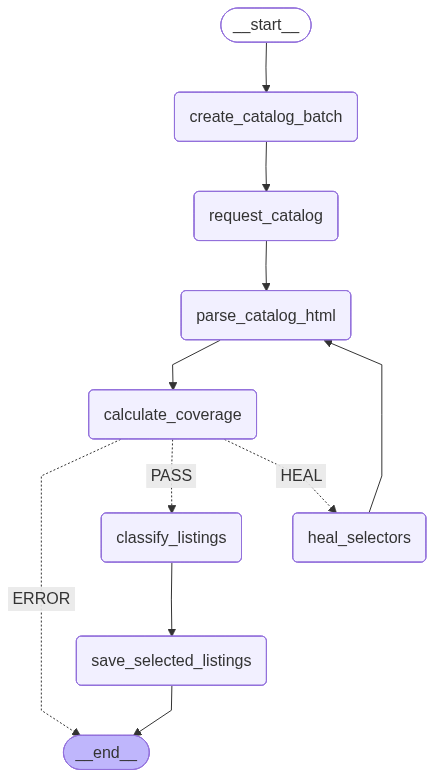

In [13]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from typing import TypedDict, NotRequired
from IPython.display import Image, display

# discrete steps for workflow: 
# 1. get_catalog_html(brand : str) -> str, sets off the CDP workflow to navigate to the catalog and download html 
# in the /db/html/catalog directory with structure, returns the name of the file
# 2. parse_catalog_html(path : str, selectors : dict) -> dict with total coverage of each field 
# 3. if coverage is not high enough, repeat again, but allow the model to change selectors and repeat until
# until the fields are found
# 4. select_worthy_listings(listings : list) -> list, takes max 3 listings, returns max 3 listings, 
# state is then state to either: ignore, mark, or notify immediately 
# 5. save_listings(listings : list) -> int, saves worthy listings to SQLite 

class Listing: # just to standardize what listings can contain, doesn't do anything else 
    def __init__(self): # all fields required except for final_price 
        self.price = None
        self.final_price = None # optional
        self.size = None
        self.image_url = None
        self.individual_url = None

class ListingSelectionState(TypedDict):
    brand: str
    batch_id: NotRequired[str]  # 5 character UUID
    scrape_config: NotRequired[dict]  # pull from dom_config.json

    listings: NotRequired[list[Listing]]
    selected_listings: NotRequired[list[Listing]]
    discarded_listings: NotRequired[list[Listing]]
    confusing_listings: NotRequired[list[Listing]]

    catalog_html_path: NotRequired[str]  # path to html file
    last_coverage: NotRequired[dict]  # size, price, final_price, image_url, individual_url
    selector_history: NotRequired[list]  # prev dom selectors
    retries: NotRequired[int]
    failed_fields: NotRequired[list]

# store in db/html like: 
# brand_name = folder.
# file is named: date(format: M/D/Y - 000000), batch_id.
# full example for storing an undercover search on july 16 2026
# stored in "db/html/catalog/undercover" directory as "071626_0682s2.html"
# helper html functions generate_catalog_html() and fetch_catalog_html() inside of src/scraper/tools/html.py
class ListingSelectionAgent:
    def __init__(self, brand: str):
        self.brand = brand
        self.graph = self.build_graph()

    def build_graph(self):
        builder = StateGraph(ListingSelectionState)
        builder.add_node("create_catalog_batch", self.create_catalog_batch)
        builder.add_node("request_catalog", self.request_catalog)
        builder.add_node("parse_catalog_html", self.parse_catalog_html)
        builder.add_node("calculate_coverage", self.calculate_coverage)
        builder.add_node("heal_selectors", self.heal_selectors)
        builder.add_node("classify_listings", self.classify_listings)
        builder.add_node("save_selected_listings", self.save_selected_listings)

        builder.set_entry_point("create_catalog_batch")
        builder.add_edge("create_catalog_batch", "request_catalog")
        builder.add_edge("request_catalog", "parse_catalog_html")
        builder.add_edge("parse_catalog_html", "calculate_coverage")
        builder.add_conditional_edges("calculate_coverage", self.route_coverage, {
            "HEAL": "heal_selectors",
            "PASS": "classify_listings",
            "ERROR": END,
        })
        builder.add_edge("heal_selectors", "parse_catalog_html")
        builder.add_edge("classify_listings", "save_selected_listings")
        builder.add_edge("save_selected_listings", END)

        return builder.compile()

    def route_coverage(self, state: ListingSelectionState) -> str:
        if state.get("retries", 0) >= 3:
            return "ERROR"
        if state.get("failed_fields"):
            return "HEAL"
        return "PASS"

    def create_catalog_batch(self, state: ListingSelectionState) -> dict:
        pass  # batch_id = generate_catalog_html(state["brand"])

    def request_catalog(self, state: ListingSelectionState) -> dict:
        pass  # exists = check_catalog_html(state["brand"], state["batch_id"])

    def parse_catalog_html(self, state: ListingSelectionState) -> dict:
        pass  # use html_tools with scrape_config

    def calculate_coverage(self, state: ListingSelectionState) -> dict:
        pass  # listings = state["listings"], calculate percentages for each field

    def heal_selectors(self, state: ListingSelectionState) -> dict:
        pass
        # last_coverage = state["last_coverage"]
        # selector_history = state["selector_history"]
        # goal_prompt = ""
        # tool_context = ""       # html tool context
        # dynamic_context = ""    # format last_coverage and selector_history for llm
        # full_prompt = ""        # format goal prompt, tool_context, and dynamic_context
        # make llm call with prompt, get new selectors
        # return { "scrape_config": new_scrape_config }

    def classify_listings(self, state: ListingSelectionState) -> dict:
        pass
        # listings = state["listings"]
        # using three listings at a time, prompt an LLM and classify into one of three categories:
        # selected, discarded, confused
        # loop until "selected" contains 3 listings, check at the end of each LLM call
        # return { "selected_listings": [], "discarded_listings": [], "confusing_listings": [] }

    def save_selected_listings(self, state: ListingSelectionState) -> dict:
        pass

    def get_listings(self) -> dict:  # just returns current listings, more just for context
        return {}


class OrchestratorState(TypedDict):
    messages: str
    source_listing: dict
    sold_listings: list
    flags: list  # shared variable that needs watchers for when changed

class OrchestratorAgent:
    def __init__(self): pass


agent = ListingSelectionAgent("undercover")
display(Image(agent.graph.get_graph().draw_mermaid_png()))
